# Gradient Boosting Regressor (GBR)

**Reduced feature set (feature extraction using PCA)**

Author: Pete King

Here we introduce a reduced feature set produced using Principal Component Analysis (PCA) and compare results to a GBR using the full feature set.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

from helpers import data_prep as dp

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'downsample' / 'W' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_PCA_data.csv'
VAL_DATA_FILE = DATA_DIR / 'val_PCA_data.csv'
TICKER = 'SPY'

## I. Import data


In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Select extracted features, returns, and historical volatility for the asset
p = re.compile(r'PCA.+')
data_cols = [col for col in train_df.columns if p.match(col) is not None]
data_cols = data_cols + [f'{TICKER}_ret-h', f'{TICKER}_vol-h']
label_col = [TICKER + '_vol_target']
train_df[data_cols]

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,PCA_hret-1,PCA_hret-2,PCA_hret-3,SPY_ret-h,SPY_vol-h
date,,,,,,,,,,,,,,,
2015-10-11,0.020393,-0.050569,-0.083967,-0.058499,-0.067576,-0.002795,-0.072643,-0.079753,-0.077507,0.104312,0.002316,-0.090883,-0.038069,0.014307,0.009701
2015-10-18,0.144258,0.192679,0.113998,0.055174,0.166992,0.274276,0.162710,0.094806,0.020584,0.025118,-0.079002,-0.063618,-0.125022,0.008646,0.007959
2015-10-25,-0.056647,-0.121334,-0.111703,-0.079352,-0.104368,-0.112265,-0.092717,-0.139361,-0.126741,-0.026842,0.062775,0.137901,-0.058733,0.020152,0.009382
2015-11-01,-0.094917,-0.100208,-0.130422,-0.170856,-0.163098,-0.172140,-0.177181,-0.103069,-0.153181,-0.053642,-0.100108,-0.192236,-0.164075,0.004483,0.005598
2015-11-08,-0.147312,-0.094768,-0.184241,-0.089133,0.072228,0.023532,-0.047020,-0.073972,-0.018724,-0.103848,-0.095369,-0.133983,-0.082019,-0.001665,0.005607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-30,0.098672,0.161029,-0.227526,0.136163,0.062461,-0.004914,0.156810,0.008527,-0.395601,-0.118113,0.114547,-0.234414,-0.077232,0.026438,0.014405
2022-11-06,-0.083704,-0.022727,0.023433,0.075600,0.020540,0.339727,0.243327,0.262418,-0.089171,0.264705,0.204808,0.100751,-0.195060,-0.025862,0.014347
2022-11-13,0.645380,-0.089868,-0.151042,0.134764,0.002418,0.286366,0.291214,-0.344037,0.419037,0.225218,-0.038603,0.300944,-0.253458,0.047693,0.026486


In [4]:
val_df[label_col]

,SPY_vol_target
date,
2023-01-01,0.010604
2023-01-08,0.010161
2023-01-15,0.010400
2023-01-22,0.010328
2023-01-29,0.010101
...,...
2024-08-04,0.011867
2024-08-11,0.009396
2024-08-18,0.008418


In [5]:
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=52,
    gap=1
)

## II. Define model, fit to data, and evaluate performance

Here we use the same parameters from our grid search using the full feature set.

In [6]:
# Define model, metrics, and Grid Search for hyperparameter tuning
reg = GradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.01,
    max_features='sqrt',
    max_depth=2,
    n_estimators=1000
)

In [7]:
reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'absolute_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thele

### Visualize performance; Check evaluation metrics

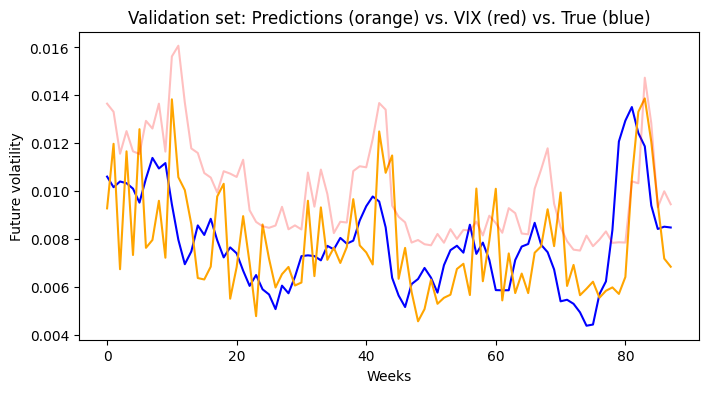

In [8]:
# Make predictions
preds = reg.predict(X_val)
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
x = range(len(y_val))
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)
fig.savefig(IMAGE_DIR / 'W-GBR-PCA')

In [9]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(y_val, preds)
    / mean_absolute_error(y_val, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(y_val, preds):.5f}')
    print(f'VIX {metric}:   {scorer(y_val, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00185
VIX MAE:   0.00249
---
Model R2: -0.31238
VIX R2:   -1.11244
---
Model R2-OOS: 0.26


The GBR model manages to out-perform the baseline model (VIX) when we use the only returns, historical volatility, and extracted features.

## III. Inspect model


In [10]:
feature_importances = list(
    zip(reg.feature_names_in_, reg.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

SPY_vol-h: 0.360
SPY_ret-h: 0.142
PCA_hvol-4: 0.069
PCA_hvol-2: 0.054
PCA_macro-4: 0.054
PCA_hvol-1: 0.048
PCA_macro-2: 0.047
PCA_macro-1: 0.037
PCA_macro-3: 0.033
PCA_hret-2: 0.031
PCA_hret-1: 0.030
PCA_vol-1: 0.027
PCA_hret-3: 0.025
PCA_hvol-3: 0.023
PCA_vol-2: 0.021


Historical volatility for the asset itself was by far the most important feature for the GBR's decisions.  We also notice that, in contrast to how imporant the volatility indicies (VIX, VXN, and MOVE) were to the Ridge regressor with the full feature set, they rank rather low for the GBR with extracted features.  This may be due to the high correlation between the asset's own historical volatility and the volatility indicies.